### Para desenhar passo a passo a arquitetura da CNN

In [48]:
#%pip install torchviz

In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from PIL import Image
from torchviz import make_dot #requer install

### Exemplo de uma MLP com duas camadas ocultas, cada uma com RELU em seus neurônios

In [47]:
#Exemplo 1
import torch
import torch.nn as nn

class myMLP(nn.Module):
    def __init__(self):
        super(myMLP, self).__init__()
        self.layer1 = nn.Linear(4, 5) #4 neuronios de entrada e 5 de saida
        self.layer2 = nn.Linear(5, 5) #conecta os 5 da camada anterior com os cinco desta camada
        self.layer3 = nn.Linear(5, 3) #conecta os 5 da camada anteiror com os tres desta camada

    def forward(self, x):
        layer1_output = torch.relu(self.layer1(x)) #saida da camada 1 com relu
        layer2_output = torch.relu(self.layer2(layer1_output)) #saida da camada 2 com relu
        y = self.layer3(layer2_output) #saida normal, regressao
        return y
        """
        A função de encaminhamento aplica as camadas aos dados de entrada (x),
        passando a saída de cada camada para a próxima e, por fim, retornando a saída da
        última camada (que contém o vetor de previsão do rótulo, y).
        Uma função de ativação reLU (unidade linear) corrigida é aplicada às saídas das
        camadas 1 e 2 para restringir os valores de saída a números positivos.
        """
# Move the model to the GPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
net = myMLP().to(device)
#Primeira camada linear
fc = net.layer1
print('First Linear Layer :',fc)

First Linear Layer : Linear(in_features=4, out_features=5, bias=True)


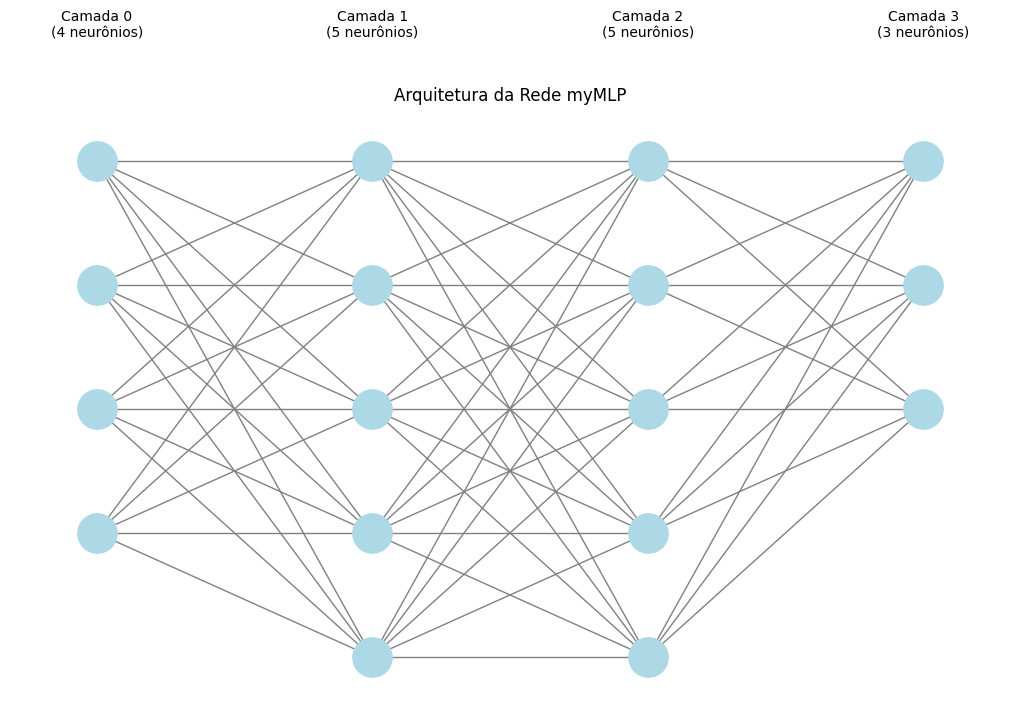

In [42]:
import matplotlib.pyplot as plt
import networkx as nx

def plot_mlp(layer_sizes):
    """
    layer_sizes: lista com o número de neurônios por camada
                 ex: [4, 5, 5, 3]
    """
    G = nx.DiGraph()
    pos = {}
    layer_distance = 4
    neuron_distance = 1.2

    # Criar nós
    for layer_idx, layer_size in enumerate(layer_sizes):
        for neuron_idx in range(layer_size):
            node_id = f"L{layer_idx}N{neuron_idx}"
            G.add_node(node_id)

            # Posição dos nós no plot
            pos[node_id] = (
                layer_idx * layer_distance,
                -neuron_idx * neuron_distance
            )

    # Criar conexões
    for layer_idx in range(len(layer_sizes) - 1):
        for i in range(layer_sizes[layer_idx]):
            for j in range(layer_sizes[layer_idx + 1]):
                src = f"L{layer_idx}N{i}"
                dst = f"L{layer_idx+1}N{j}"
                G.add_edge(src, dst)

    # Plotar
    plt.figure(figsize=(10, 6))
    nx.draw(
        G, pos,
        with_labels=False,
        arrows=False,
        node_size=800,
        node_color="lightblue",
        edge_color="gray"
    )

    # Legendas das camadas
    for layer_idx, size in enumerate(layer_sizes):
        x = layer_idx * layer_distance
        y = 1.2
        plt.text(x, y, f"Camada {layer_idx}\n({size} neurônios)",
                 horizontalalignment='center')

    plt.title("Arquitetura da Rede myMLP")
    plt.axis("off")
    plt.show()


# ------- USO -------
layer_sizes = [4, 5, 5, 3]  # da sua rede: entrada, layer1, layer2, layer3
plot_mlp(layer_sizes)


### Uso da rede MLP para regressão com dados hipotéticos

Epoch 50: loss = 3.8914
Epoch 100: loss = 3.6823
Epoch 150: loss = 3.6425
Epoch 200: loss = 3.6236
Epoch 250: loss = 3.6128
Epoch 300: loss = 3.6051

Entrada nova: tensor([[ 0.1000, -0.3000,  0.5000,  1.2000]])
Predição da rede: tensor([[1.4504, 1.5517, 1.6216]])


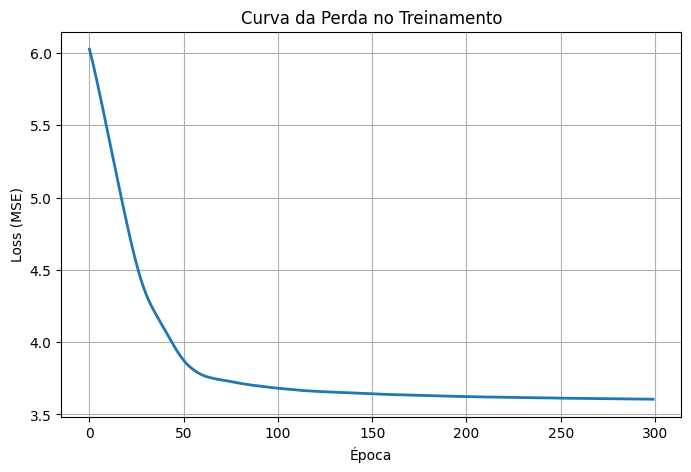

In [52]:
# ------- DATASET HIPOTÉTICO -------
# x tem 4 features, y tem 3 saídas (regressão)
torch.manual_seed(0)

amostras = 500

X = torch.randn(amostras, 4)               # entrada 4D
Y = torch.randn(amostras, 3) * 2 + 1.5     # saída 3D (exemplo)


# ------- INSTANCIAR A REDE -------
model = myMLP()

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_history = []

# ------- TREINAMENTO -------
epochs = 300

for epoch in range(epochs):
    optimizer.zero_grad()

    y_pred = model(X)

    loss = criterion(y_pred, Y)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())  # salva perda

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}: loss = {loss.item():.4f}")


# ------- TESTE DA REDE COM NOVO DADO -------
x_new = torch.tensor([[0.1, -0.3, 0.5, 1.2]])  # exemplo de entrada

y_new = model(x_new)

print("\nEntrada nova:", x_new)
print("Predição da rede:", y_new.detach())

# ------- GRÁFICO DA CURVA DE LOSS -------
plt.figure(figsize=(8,5))
plt.plot(loss_history, linewidth=2)
plt.xlabel("Época")
plt.ylabel("Loss (MSE)")
plt.title("Curva da Perda no Treinamento")
plt.grid(True)
plt.show()

### Apenas para comparação uma regressão linear múltipla na mesma base hipotética

In [53]:
import numpy as np
import torch
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# ------- MESMO DATASET HIPOTÉTICO -------
torch.manual_seed(0)
N_amostras = 500

X = torch.randn(N_amostras, 4)
Y = torch.randn(N_amostras, 3) * 2 + 1.5

# Converter para numpy (scikit-learn usa numpy)
X_np = X.numpy()
Y_np = Y.numpy()

# ------- REGRESSÃO LINEAR MÚLTIPLA -------
model_lr = LinearRegression()
model_lr.fit(X_np, Y_np)

# Previsões
Y_pred_lr = model_lr.predict(X_np)

# Cálculo do erro
mse = mean_squared_error(Y_np, Y_pred_lr)
print("MSE (Regressão Linear Múltipla):", mse)

# Exemplo de predição com novo dado
x_new = np.array([[0.1, -0.3, 0.5, 1.2]])
y_new_lr = model_lr.predict(x_new)

print("\nEntrada nova:", x_new)
print("Predição da Regressão Linear:", y_new_lr)

MSE (Regressão Linear Múltipla): 3.702744245529175

Entrada nova: [[ 0.1 -0.3  0.5  1.2]]
Predição da Regressão Linear: [[1.33084234 1.37167919 1.46643062]]


### Agora criando uma CNN com Pytorch apenas para verificar passo a passo a construção das camadas e blocos

In [35]:
#construir a rede neural
# Define a neural network architecture
class myFirstCNN(nn.Module):
    def __init__(self):
        super(myFirstCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3) #IN: imagem com 3 canais (RGB), OUT (filters): 16 mapas de características, Kernel: 3×3
                                         #Sem padding → diminui a imagem em 2 pixels (1 de cada lado)
        """
        Após a convolução, a imagem fica sem padding (W - 2) × (H - 2)
        """
        self.pool = nn.MaxPool2d(3, 2) #Janela 3×3, Stride 2 (reduzir dimensionalidade)
        """
        Após MaxPool 3x3, stride 2, fica = (W−2)−3)/2​+1 * 16 canais * ((H-2)-3)/2 + 1
        """
        self.fc1 = nn.Linear(203, 120) #Recebe um vetor flattened de In: tamanho 203 (Calculo do H anterior) ()
        self.fc2 = nn.Linear(120,1) #Retorna um único valor, útil para classificação binária ou regressão
        self.fc3 = nn.Sigmoid() #aplica regressão logística (probabilidade)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x))) #Convolução 3→16 canais
        x = x.view(-1, 203)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Move the model to the GPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
net = myFirstCNN().to(device)

cpu


In [29]:
# Load the image
img = Image.open("car.png").convert('RGB') #735 410

# Transformation
transform = transforms.Compose([
    #transforms.Resize((735, 410)),  # Resize the image to W x H
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

img = transform(img)
# Reshape the 4d tensor
img = img.view(1, 3, 735, 410)

# Move to GPU
img = img.to(device)
img.shape

torch.Size([1, 3, 735, 410])

Convolution Layer : Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
Output Shape : torch.Size([1, 16, 733, 408])


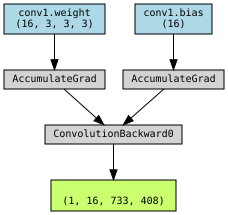

In [30]:
# first convolutional layer
conv1 = net.conv1
print('Convolution Layer :',conv1)

# APPLY THE FIRST Convolutional layer to the image
y1 = conv1(img)
print('Output Shape :',y1.shape)

# Computational Graph
make_dot(y1, params=dict(net.named_parameters()))

pooling Layer : MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
Output Shape : torch.Size([1, 16, 366, 203])


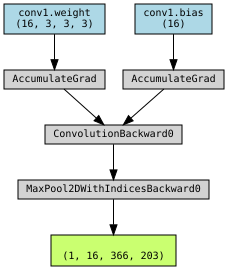

In [31]:
# Pooling layer
pool = net.pool
print('pooling Layer :',pool)

# APPLY THE Pooling layer to the
# output of FIRST Convolutional layer
y2 = pool(y1)
print('Output Shape :',y2.shape)

# Computational Graph
make_dot(y2, params=dict(net.named_parameters()))

First Linear Layer : Linear(in_features=203, out_features=120, bias=True)
Output Shape : torch.Size([1, 16, 366, 120])


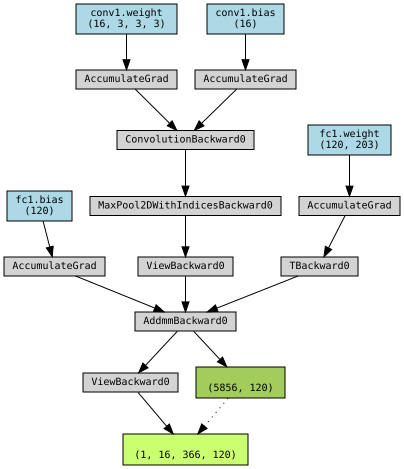

In [32]:
#Primeira camada linear
fc = net.fc1
print('First Linear Layer :',fc)

# APPLY THE Linear layer to the output y2
y3 = fc(y2)
print('Output Shape :',y3.shape)

# Computational Graph
make_dot(y3, params=dict(net.named_parameters()))

Second Linear Layer : Linear(in_features=120, out_features=1, bias=True)
Output Shape : torch.Size([1, 16, 366, 1])


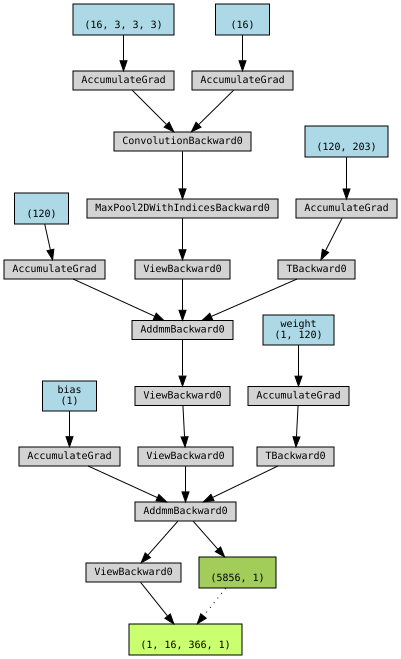

In [33]:
# Second Linear layer
fc_2 = net.fc2
print('Second Linear Layer :',fc_2)

# APPLY THE Second Linear layer to the output y3
y4 = fc_2(y3)
print('Output Shape :',y4.shape)

# Computational Graph
make_dot(y4, params=dict(fc_2.named_parameters()))

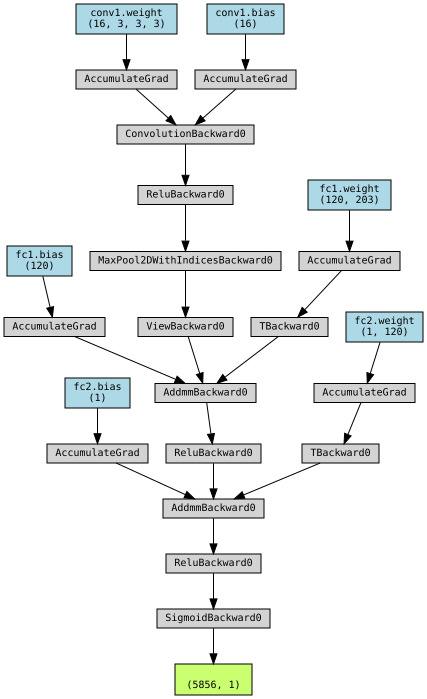

In [34]:
# define labels
labels = torch.rand(1).to(device)

# forward propagation
prediction = net(img)

# define loss
loss = (prediction - labels).sum()

# backward pass
loss.backward()
# Optimizer
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

# gradient descent
optimizer.step()

# Computational Graph
make_dot(prediction,
         params=dict(net.named_parameters()))